# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


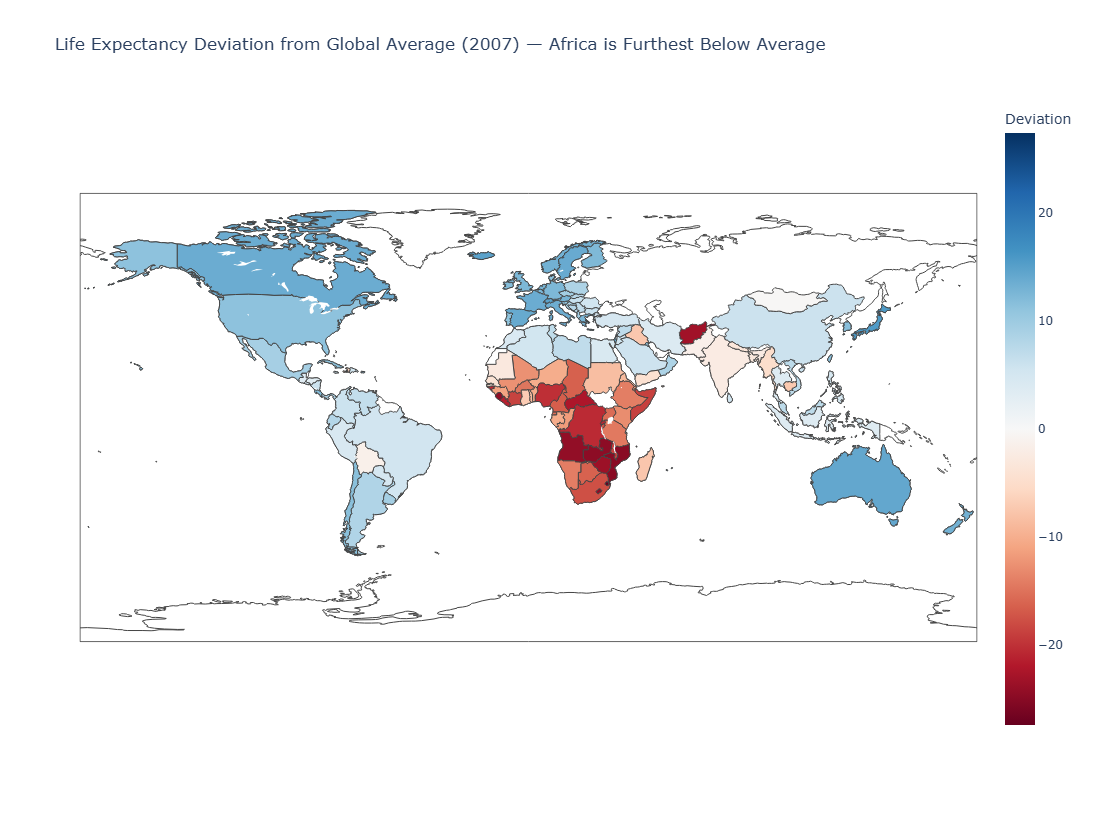

In [6]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# Load Gapminder dataset (2007 only)
gm = px.data.gapminder()
gm_2007 = gm[gm['year'] == 2007].copy()

# Compute global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# Compute deviation from global average
gm_2007['lifeExp_dev'] = gm_2007['lifeExp'] - global_avg

# Find region furthest below average
region_dev = (
    gm_2007.groupby('continent')['lifeExp_dev']
    .mean()
    .sort_values()
)

worst_region = region_dev.index[0]

# Create choropleth
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='lifeExp_dev',
    hover_name='country',
    hover_data={
        'lifeExp': ':.2f',
        'lifeExp_dev': ':.2f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title=f'Life Expectancy Deviation from Global Average (2007) — {worst_region} is Furthest Below Average',
    width=1400,   
    height=800    
)

# Improve layout
fig.update_layout(
    coloraxis_colorbar_title='Deviation',
    template='plotly_white'
)

fig.show()

Life expectancy in 2007 showed a strong geographic divide relative to the global average.
Most countries in Africa were significantly below the world mean, while Western Europe, Japan, and Australia were well above it.
The diverging colour scale clearly highlighted regions outperforming or underperforming the global benchmark.
Africa emerged as the continent furthest below the global average life expectancy.

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*
Natural Earth admin boundaries from geojson.xyz

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**
px.choropleth

Reason:
I chose px.choropleth because this task uses polygon region boundaries (countries/states) and does not require a Mapbox token or street basemap. A standard choropleth is simpler, cleaner, and faster for thematic regional comparisons.

**Colour scale chosen** (sequential or diverging) **and reason:**
Sequential scale (Viridis)

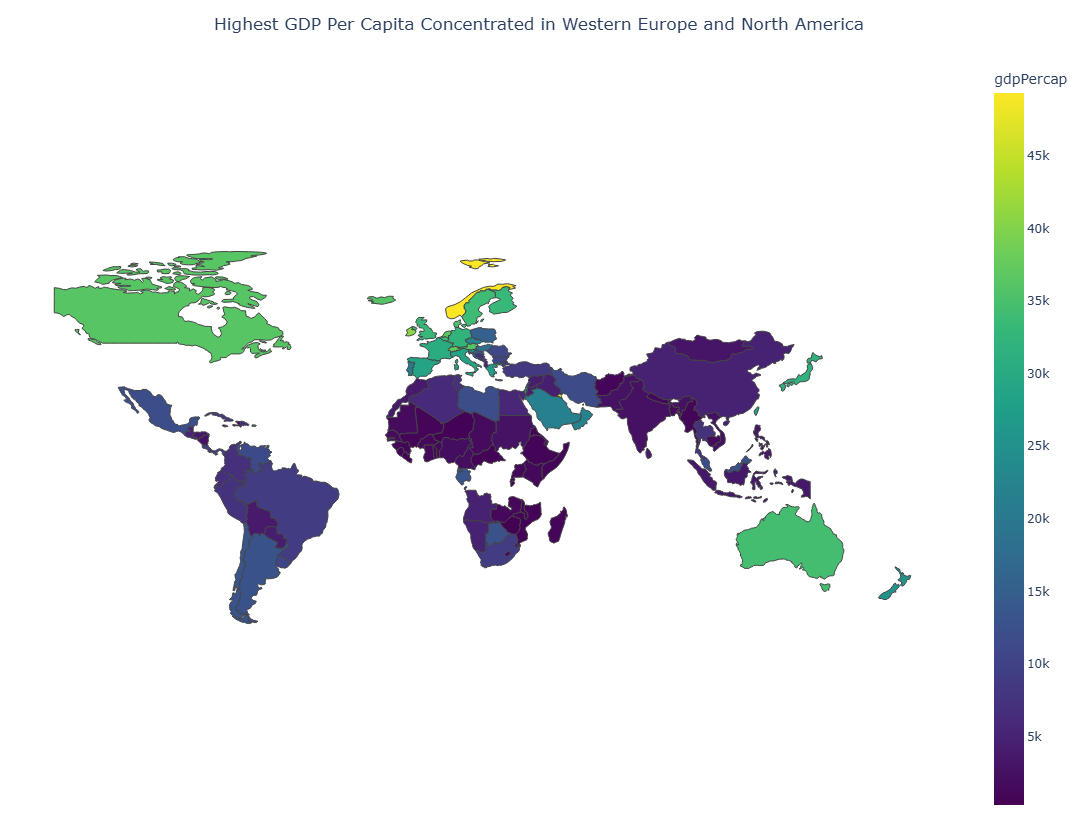

In [12]:
# Task 2
# YOUR CODE HERE

# Load your GeoJSON
# with open('your_file.geojson', 'r') as file:
#     my_geojson = json.load(file)

# Inspect the properties to find the right featureidkey
# print(my_geojson['features'][0]['properties'])
import pandas as pd
import plotly.express as px
import requests

# ---------------------------------------
# Load GeoJSON (countries)
# ---------------------------------------

geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"

geojson = requests.get(geojson_url).json()

# Inspect GeoJSON properties
#print(geojson['features'][0]['properties'])

# ---------------------------------------
# Load dataset
# ---------------------------------------

gm = px.data.gapminder()
gm_2007 = gm[gm['year'] == 2007]

# Use GDP per capita by country
df = gm_2007[['country', 'gdpPercap']]

# ---------------------------------------
# Build choropleth
# ---------------------------------------

fig = px.choropleth(
    df,
    geojson=geojson,
    locations='country',
    featureidkey='properties.name',
    color='gdpPercap',
    color_continuous_scale='Viridis',
    hover_name='country',
    hover_data={'gdpPercap': ':.0f'},
    title='Highest GDP Per Capita Concentrated in Western Europe and North America',
    width=1400,
    height=800
)

# Remove borders/extra labels
fig.update_geos(
    fitbounds="locations",
    visible=False
)

# Cleaner layout
fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    margin={"r":0, "t":60, "l":0, "b":0}
)

# Better hover formatting
fig.update_traces(
    hovertemplate="<b>%{location}</b><br>GDP per Capita: %{z:.0f}<extra></extra>"
)

fig.show()


GDP per capita in 2007 was heavily concentrated in North America and Western Europe.
Countries across Africa and parts of South Asia showed comparatively lower economic output per person.
The sequential colour scale effectively emphasized the gradual increase from low- to high-income regions.
Luxembourg and several Western European countries stood out as the highest GDP-per-capita regions globally.